#10/5/26
#Author: Alma Plaa-Rodriguez



# This notebook performs quality control on PANC1-Gemcitabine treated cell data downloaded and imported from GEO

In [18]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

ctrl = pd.read_csv(
    "/mnt/research/HFHMSU-Pancreas/AlmaP_Project_data/Gem_Panc1/GSM5664353_PANC1CTRL.dge.txt.gz",
    sep="\t",
    compression="gzip"
)

gem24h = pd.read_csv(
    "/mnt/research/HFHMSU-Pancreas/AlmaP_Project_data/Gem_Panc1/GSM5664354_PANC1GEM24H.dge.txt.gz",
    sep="\t",
    compression="gzip"
)

print("CTRL:", ctrl.shape)
print("GEM 24h:", gem24h.shape)

display(ctrl.head())

CTRL: (24339, 17836)
GEM 24h: (25263, 17883)


,GENE,AAAAAACAAGTT,AAAAAACACCGT,AAAAAACATAAG,AAAAAAGACGGC,AAAAAAGGCTTC,AAAAAATGTCCC,AAAAAATTGCAA,AAAAACCCGTAG,AAAAACCTTGGA,...,TTTTTGGTAGGC,TTTTTGGTTATC,TTTTTGTACCAC,TTTTTTACGCAG,TTTTTTCATTTT,TTTTTTCCGCCT,TTTTTTCGGCTC,TTTTTTGCTAGT,TTTTTTTGCCCG,TTTTTTTTTTTT
0,A1BG,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,A1BG-AS1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,A2M-AS1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,A2ML1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,A4GALT,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Import the data and convert into an anndata file

In [23]:
import pandas as pd
from pandas._config.config import register_option
from pandas._config.config import OptionError

try:
    pd.get_option("future.infer_string")
except OptionError:
    register_option(
        "future.infer_string",
        False,
        doc="Compatibility option required by newer anndata."
    )

In [19]:
print(ctrl.columns[:10])
print(ctrl.iloc[:5, :5])

Index(['GENE', 'AAAAAACAAGTT', 'AAAAAACACCGT', 'AAAAAACATAAG', 'AAAAAAGACGGC',
       'AAAAAAGGCTTC', 'AAAAAATGTCCC', 'AAAAAATTGCAA', 'AAAAACCCGTAG',
       'AAAAACCTTGGA'],
      dtype='object')
       GENE  AAAAAACAAGTT  AAAAAACACCGT  AAAAAACATAAG  AAAAAAGACGGC
0      A1BG             0             0             0             0
1  A1BG-AS1             0             0             0             0
2   A2M-AS1             0             0             0             0
3     A2ML1             0             0             0             0
4    A4GALT             0             0             0             0


In [20]:
# Make gene names the index

ctrl = ctrl.set_index("GENE")
gem24h = gem24h.set_index("GENE")

In [21]:

# =========================
# CTRL
# =========================

# Transpose: cells x genes
ctrl = ctrl.T

# Convert to sparse matrix
ctrl_sparse = sparse.csr_matrix(ctrl.values)

# Create AnnData
adata_ctrl = ad.AnnData(
    X=ctrl_sparse
)

# Add cell and gene names
adata_ctrl.obs_names = ctrl.index
adata_ctrl.var_names = ctrl.columns

# Add metadata
adata_ctrl.obs["condition"] = "CTRL"
adata_ctrl.obs["treatment"] = "Control"


# =========================
# GEM 24H
# =========================

# Transpose: cells x genes
gem24h = gem24h.T

# Convert to sparse matrix
gem_sparse = sparse.csr_matrix(gem24h.values)

# Create AnnData
adata_gem = ad.AnnData(
    X=gem_sparse
)

# Add cell and gene names
adata_gem.obs_names = gem24h.index
adata_gem.var_names = gem24h.columns

# Add metadata
adata_gem.obs["condition"] = "GEM24H"
adata_gem.obs["treatment"] = "Gemcitabine"


# =========================
# CHECK
# =========================

print(adata_ctrl)
print(adata_gem)

print("\nCTRL first cells:")
print(adata_ctrl.obs_names[:5])

print("\nCTRL first genes:")
print(adata_ctrl.var_names[:5])

print("\nGEM first cells:")
print(adata_gem.obs_names[:5])

print("\nGEM first genes:")
print(adata_gem.var_names[:5])

AnnData object with n_obs × n_vars = 17835 × 24339
    obs: 'condition', 'treatment'
AnnData object with n_obs × n_vars = 17882 × 25263
    obs: 'condition', 'treatment'

CTRL first cells:
Index(['AAAAAACAAGTT', 'AAAAAACACCGT', 'AAAAAACATAAG', 'AAAAAAGACGGC',
       'AAAAAAGGCTTC'],
      dtype='object')

CTRL first genes:
Index(['A1BG', 'A1BG-AS1', 'A2M-AS1', 'A2ML1', 'A4GALT'], dtype='object', name='GENE')

GEM first cells:
Index(['AAAAAAGGTCAC', 'AAAAACCATCCG', 'AAAAACCTGTTT', 'AAAAACTATGAG',
       'AAAAAGAACACG'],
      dtype='object')

GEM first genes:
Index(['A1BG', 'A1BG-AS1', 'A4GALT', 'A4GNT', 'AAAS'], dtype='object', name='GENE')


In [24]:
adata = ad.concat(
    {
        "CTRL": adata_ctrl,
        "GEM24H": adata_gem
    },
    join="inner",
    label="sample"
)

print(adata)

AnnData object with n_obs × n_vars = 35717 × 21867
    obs: 'condition', 'treatment', 'sample'


/mnt/home/plazarod/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [29]:
adata.var_names_make_unique()

In [30]:
adata.obs

,condition,treatment,sample
AAAAAACAAGTT,CTRL,Control,CTRL
AAAAAACACCGT,CTRL,Control,CTRL
AAAAAACATAAG,CTRL,Control,CTRL
AAAAAAGACGGC,CTRL,Control,CTRL
AAAAAAGGCTTC,CTRL,Control,CTRL
...,...,...,...
TTTTTGTAATCC,GEM24H,Gemcitabine,GEM24H
TTTTTTACCAAA,GEM24H,Gemcitabine,GEM24H
TTTTTTATCGGA,GEM24H,Gemcitabine,GEM24H
TTTTTTCATAGT,GEM24H,Gemcitabine,GEM24H


In [31]:
adata.var

""
GENE
A1BG
A1BG-AS1
A4GALT
A4GNT
AAAS
...
ZYG11A
ZYG11B
ZYX


In [28]:
adata.X

<35717x21867 sparse matrix of type '<class 'numpy.int64'>'
	with 9589546 stored elements in Compressed Sparse Row format>

In [34]:
# ==========================================
# Basic AnnData sanity checks
# ==========================================

print("AnnData:")
print(adata)

print("\nShape (cells x genes):")
print(adata.shape)

print("\nOBS:")
print(adata.obs.head())
print("\nobs columns:")
print(adata.obs.columns.tolist())

print("\nVAR:")
print(adata.var.head())

print("\nFirst 10 cell names:")
print(adata.obs_names[:10].tolist())

print("\nFirst 10 gene names:")
print(adata.var_names[:10].tolist())

print("\nUnique cell names:")
print(adata.obs_names.is_unique)

print("\nUnique gene names:")
print(adata.var_names.is_unique)

print("\nCondition counts:")
print(adata.obs["condition"].value_counts())

print("\nSample counts:")
print(adata.obs["sample"].value_counts())

print("\nTreatment counts:")
print(adata.obs["treatment"].value_counts())

print("\nMatrix type:")
print(type(adata.X))

print("\nData type:")
print(adata.X.dtype)

print("\nMin / max counts:")
print(adata.X.min(), adata.X.max())

AnnData:
AnnData object with n_obs × n_vars = 35717 × 21867
    obs: 'condition', 'treatment', 'sample'

Shape (cells x genes):
(35717, 21867)

OBS:
             condition treatment sample
AAAAAACAAGTT      CTRL   Control   CTRL
AAAAAACACCGT      CTRL   Control   CTRL
AAAAAACATAAG      CTRL   Control   CTRL
AAAAAAGACGGC      CTRL   Control   CTRL
AAAAAAGGCTTC      CTRL   Control   CTRL

obs columns:
['condition', 'treatment', 'sample']

VAR:
Empty DataFrame
Columns: []
Index: [A1BG, A1BG-AS1, A4GALT, A4GNT, AAAS]

First 10 cell names:
['AAAAAACAAGTT', 'AAAAAACACCGT', 'AAAAAACATAAG', 'AAAAAAGACGGC', 'AAAAAAGGCTTC', 'AAAAAATGTCCC', 'AAAAAATTGCAA', 'AAAAACCCGTAG', 'AAAAACCTTGGA', 'AAAAACGATGTA']

First 10 gene names:
['A1BG', 'A1BG-AS1', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADAT', 'AAED1', 'AAGAB']

Unique cell names:
False

Unique gene names:
True

Condition counts:
condition
GEM24H    17882
CTRL      17835
Name: count, dtype: int64

Sample counts:
sample
GEM24H    17882
CTRL   

In [35]:
adata.write_h5ad(
    "/mnt/research/HFHMSU-Pancreas/AlmaP_Project_data/Gem_Panc1/GSM5664353_PANC1_CTRL_GEM24H_raw.h5ad")


In [37]:
import numpy as np
print("Non-negative:", np.all(adata.X.data >= 0))
print("Integer-valued:", np.all(adata.X.data == np.floor(adata.X.data)))

Non-negative: True
Integer-valued: True


# Perform QC

In [40]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Mark mitochondrial genes
# --------------------------------------------------
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

# Optional: ribosomal genes
adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))

# --------------------------------------------------
# 2. Calculate QC metrics
# --------------------------------------------------
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Inspect newly added QC columns
print(adata.obs.columns.tolist())

# --------------------------------------------------
# 3. Summary statistics by condition
# --------------------------------------------------
qc_summary = (
    adata.obs.groupby("condition")[
        [
            "total_counts",
            "n_genes_by_counts",
            "pct_counts_mt",
            "pct_counts_ribo"
        ]
    ]
    .describe()
)

display(qc_summary)

/mnt/home/plazarod/.local/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


['condition', 'treatment', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo']


total_counts                                                     \
                 count        mean          std  min    25%    50%    75%   
condition                                                                   
CTRL           17835.0  535.295879  2205.149857  2.0  112.0  135.0  188.0   
GEM24H         17882.0  583.074376  3170.593115  4.0  150.0  180.0  246.0   

                   n_genes_by_counts              ... pct_counts_mt  \
               max             count        mean  ...           75%   
condition                                         ...                 
CTRL       49789.0           17835.0  258.829437  ...     12.389381   
GEM24H     96251.0           17882.0  278.118946  ...      8.988764   

                     pct_counts_ribo                                       \
                 max           count       mean       std  min        25%   
condition                                                                   
CTRL       92.359667         17835.0  15.828312  4.345846  0.0  13.285719   
GEM24H     91.266376         17882.0  14.421919  3.758401  0.0  12.138728   

                                            
                 50%        75%        max  
condition                                   
CTRL       15.929204  18.548387  66.666667  
GEM24H     14.405036  16.780247  41.666667  

[2 rows x 32 columns]

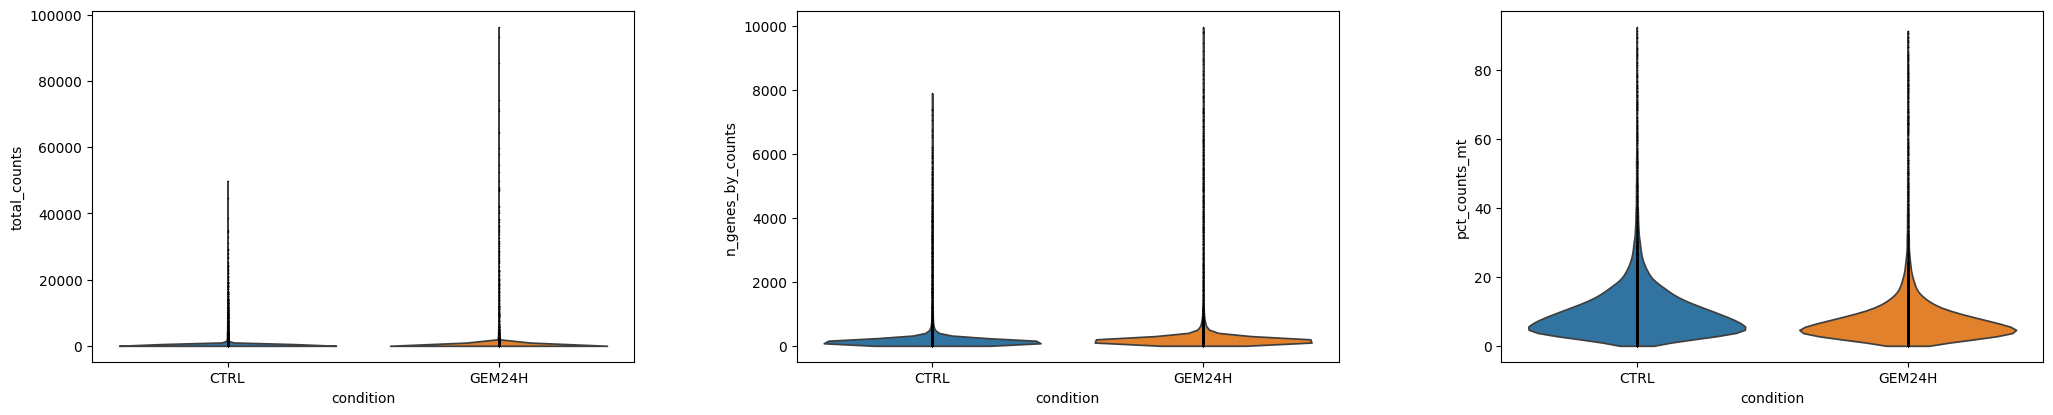

In [42]:
sc.pl.violin(
    adata,
    keys=[
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt"
    ],
    groupby="condition",
    jitter=False,
    multi_panel=True
)

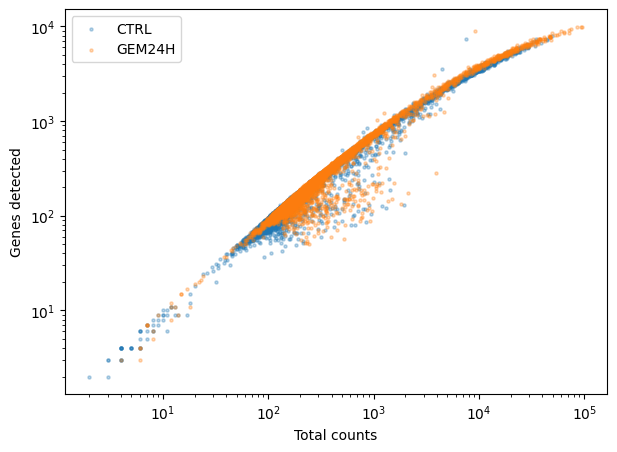

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

for condition in adata.obs["condition"].unique():
    subset = adata.obs[adata.obs["condition"] == condition]

    ax.scatter(
        subset["total_counts"],
        subset["n_genes_by_counts"],
        s=5,
        alpha=0.3,
        label=condition
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total counts")
ax.set_ylabel("Genes detected")
ax.legend()
plt.show()

In [44]:
qc_medians = (
    adata.obs.groupby("condition")[
        [
            "total_counts",
            "n_genes_by_counts",
            "pct_counts_mt",
            "pct_counts_ribo"
        ]
    ]
    .median()
)

display(qc_medians)

,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo
condition,,,,
CTRL,135.0,112.0,7.894737,15.929204
GEM24H,180.0,149.0,5.821012,14.405036


In [45]:
adata_raw = adata.copy()

/mnt/home/plazarod/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [46]:


qc_check = pd.DataFrame({
    "all_cells": adata.obs.groupby("condition").size(),
    "genes>=50": adata.obs[adata.obs["n_genes_by_counts"] >= 50]
                       .groupby("condition").size(),
    "genes>=100": adata.obs[adata.obs["n_genes_by_counts"] >= 100]
                        .groupby("condition").size(),
    "mt<20%": adata.obs[adata.obs["pct_counts_mt"] < 20]
                    .groupby("condition").size(),
    "mt<25%": adata.obs[adata.obs["pct_counts_mt"] < 25]
                    .groupby("condition").size()
})

qc_check

,all_cells,genes>=50,genes>=100,mt<20%,mt<25%
condition,,,,,
CTRL,17835,17731,11858,16469,17102
GEM24H,17882,17852,17364,17077,17351


In [47]:
adata_qc = adata[
    (adata.obs["n_genes_by_counts"] >= 50) &
    (adata.obs["pct_counts_mt"] < 20)
].copy()

/mnt/home/plazarod/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [48]:
print("Before:")
print(adata.obs["condition"].value_counts())

print("\nAfter:")
print(adata_qc.obs["condition"].value_counts())

print("\nFraction retained:")
print(
    adata_qc.obs["condition"].value_counts()
    / adata.obs["condition"].value_counts()
)

Before:
condition
GEM24H    17882
CTRL      17835
Name: count, dtype: int64

After:
condition
GEM24H    17058
CTRL      16404
Name: count, dtype: int64

Fraction retained:
condition
GEM24H    0.953920
CTRL      0.919765
Name: count, dtype: float64


In [49]:
# Remove mitochondrial + ribosomal genes
keep_genes = ~(
    adata_qc.var["mt"] |
    adata_qc.var["ribo"]
)

print("Genes before:", adata_qc.n_vars)

adata_qc = adata_qc[:, keep_genes].copy()

print("Genes after removing MT/ribo:", adata_qc.n_vars)

# Remove extremely rare genes
sc.pp.filter_genes(
    adata_qc,
    min_cells=3
)

print("Genes after min_cells=3:", adata_qc.n_vars)
print(adata_qc)

Genes before: 21867
Genes after removing MT/ribo: 21076
Genes after min_cells=3: 20107
AnnData object with n_obs × n_vars = 33462 × 20107
    obs: 'condition', 'treatment', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'condition_colors'


/mnt/home/plazarod/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/mnt/home/plazarod/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [54]:
# Preserve raw counts
adata_qc.layers["counts"] = adata_qc.X.copy()

import numpy as np

# Calculate library size directly from the QC-filtered raw matrix
library_sizes = np.asarray(adata_qc.X.sum(axis=1)).ravel()

median_library_size = np.median(library_sizes)

print("Median library size:", median_library_size)

Median library size: 509.68774


In [52]:
adata.obs.groupby("condition")["total_counts"].describe()

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
CTRL,17835.0,535.295879,2205.149857,2.0,112.0,135.0,188.0,49789.0
GEM24H,17882.0,583.074376,3170.593115,4.0,150.0,180.0,246.0,96251.0


# Normalize: library normalize and log transform your data

In [55]:
# Normalize each cell to 10,000 counts
sc.pp.normalize_total(
    adata_qc,
    target_sum=1e4
)
# log1p
sc.pp.log1p(adata_qc)

print(adata_qc)

AnnData object with n_obs × n_vars = 33462 × 20107
    obs: 'condition', 'treatment', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'condition_colors', 'log1p'
    layers: 'counts'


In [57]:
# Check one last time
print(adata_qc)
print(adata_qc.shape)
print(adata_qc.obs["condition"].value_counts())

# Save
adata_qc.write_h5ad(
    "/mnt/research/HFHMSU-Pancreas/AlmaP_Project_data/Gem_Panc1/GSM5664353_PANC1_CTRL_GEM24H_normalized.h5ad")

AnnData object with n_obs × n_vars = 33462 × 20107
    obs: 'condition', 'treatment', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'condition_colors', 'log1p'
    layers: 'counts'
(33462, 20107)
condition
GEM24H    17058
CTRL      16404
Name: count, dtype: int64
